# Predicting Remaining Useful Life of Turbofan Engines — NASA CMAPSS 

##  Setup and Data Loading 

In [3]:
import os
import pandas as pd
import numpy as np

os.chdir('/Users/adharvaturaga/Documents/Code')

columns = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

train_dfs, test_dfs, rul_dfs = [], [], []

for i in range(1, 5):
    train = pd.read_csv(f'CMaps/train_FD00{i}.txt', sep=r'\s+', header=None, names=columns)
    train = train.dropna(axis=1)
    train['dataset'] = i
    train_dfs.append(train)

    test = pd.read_csv(f'CMaps/test_FD00{i}.txt', sep=r'\s+', header=None, names=columns)
    test = test.dropna(axis=1)
    test['dataset'] = i
    test_dfs.append(test)

    rul = pd.read_csv(f'CMaps/RUL_FD00{i}.txt', header=None, names=['RUL'])
    rul_dfs.append(rul)

df_train = pd.concat(train_dfs, ignore_index=True)
df_test  = pd.concat(test_dfs,  ignore_index=True)

print("Train shape:", df_train.shape)
print("Test shape: ", df_test.shape)
df_train.head()

Train shape: (160359, 27)
Test shape:  (104897, 27)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,1


###  Looking At The Data

In [4]:
print("Total engines:", df_train['unit'].nunique())
print("\nEngines per dataset:")
for i in range(1, 5):
    subset = df_train[df_train['dataset'] == i]
    print(f"  FD00{i} -> {subset['unit'].nunique()} engines, {len(subset):,} rows")

print("\nColumns:", list(df_train.columns))
print("\nAny missing values?", df_train.isnull().sum().sum())

Total engines: 260

Engines per dataset:
  FD001 -> 100 engines, 20,631 rows
  FD002 -> 260 engines, 53,759 rows
  FD003 -> 100 engines, 24,720 rows
  FD004 -> 249 engines, 61,249 rows

Columns: ['unit', 'cycle', 'op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 'dataset']

Any missing values? 0


 ##  RUL Calculation

In [5]:
max_cycles = df_train.groupby(['dataset', 'unit'])['cycle'].max().reset_index()
max_cycles.columns = ['dataset', 'unit', 'max_cycle']

df_train = df_train.merge(max_cycles, on=['dataset', 'unit'], how='left')
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
df_train = df_train.drop('max_cycle', axis=1)

print("RUL calculated!")
print(df_train[['unit', 'cycle', 'RUL', 'dataset']].head(10))
print("\nMax RUL:", df_train['RUL'].max())
print("Min RUL:", df_train['RUL'].min())




RUL calculated!
   unit  cycle  RUL  dataset
0     1      1  191        1
1     1      2  190        1
2     1      3  189        1
3     1      4  188        1
4     1      5  187        1
5     1      6  186        1
6     1      7  185        1
7     1      8  184        1
8     1      9  183        1
9     1     10  182        1

Max RUL: 542
Min RUL: 0


## Exploratory Data Analysis

 ###  Sensor Degradation Over Time

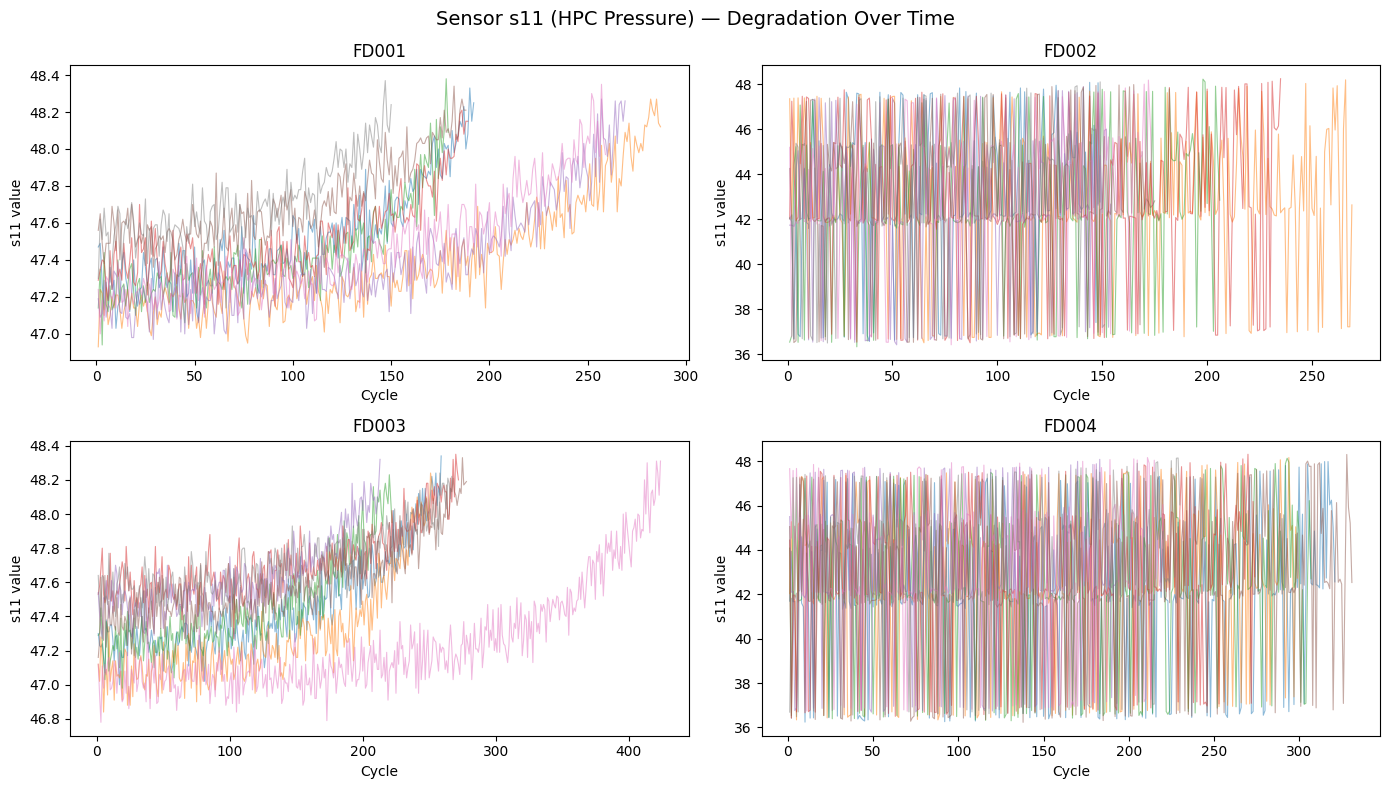

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Sensor s11 (HPC Pressure) — Degradation Over Time', fontsize=14)

for idx, dataset_num in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2][idx % 2]
    subset = df_train[df_train['dataset'] == dataset_num]
    
    for engine_id in subset['unit'].unique()[:8]:
        engine_data = subset[subset['unit'] == engine_id]
        ax.plot(engine_data['cycle'], engine_data['s11'], alpha=0.5, linewidth=0.8)
    
    ax.set_title(f'FD00{dataset_num}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('s11 value')

plt.tight_layout()
plt.show()



 ###  RUL Distribution by Datase

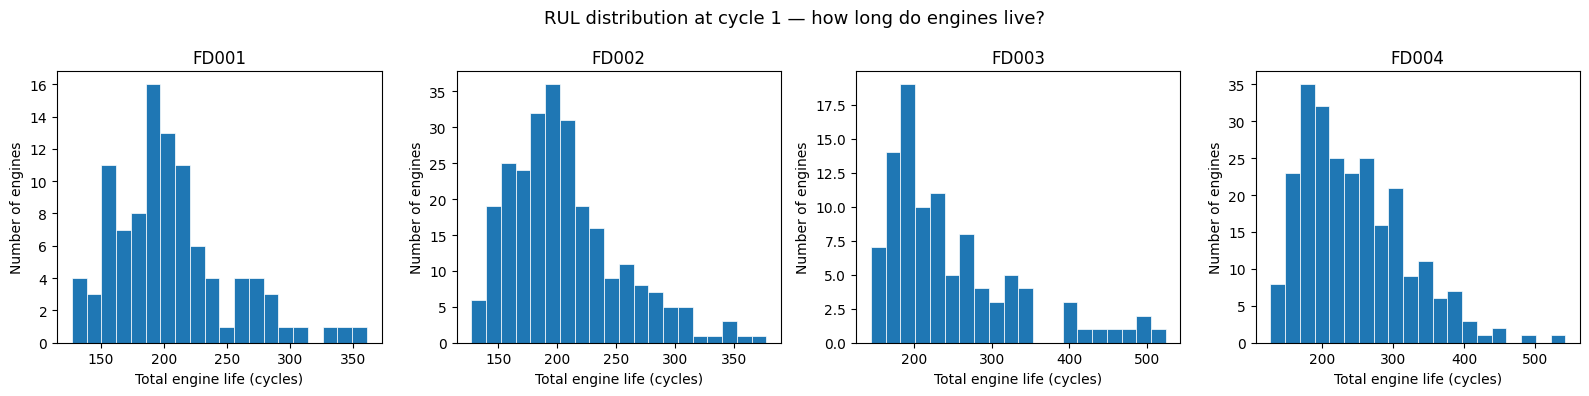

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('RUL distribution at cycle 1 — how long do engines live?', fontsize=13)

for idx, dataset_num in enumerate([1, 2, 3, 4]):
    subset = df_train[df_train['dataset'] == dataset_num]
    max_ruls = subset.groupby('unit')['RUL'].max()
    
    axes[idx].hist(max_ruls, bins=20, edgecolor='white', linewidth=0.5)
    axes[idx].set_title(f'FD00{dataset_num}')
    axes[idx].set_xlabel('Total engine life (cycles)')
    axes[idx].set_ylabel('Number of engines')

plt.tight_layout()
plt.show()


### Operating Conditions  

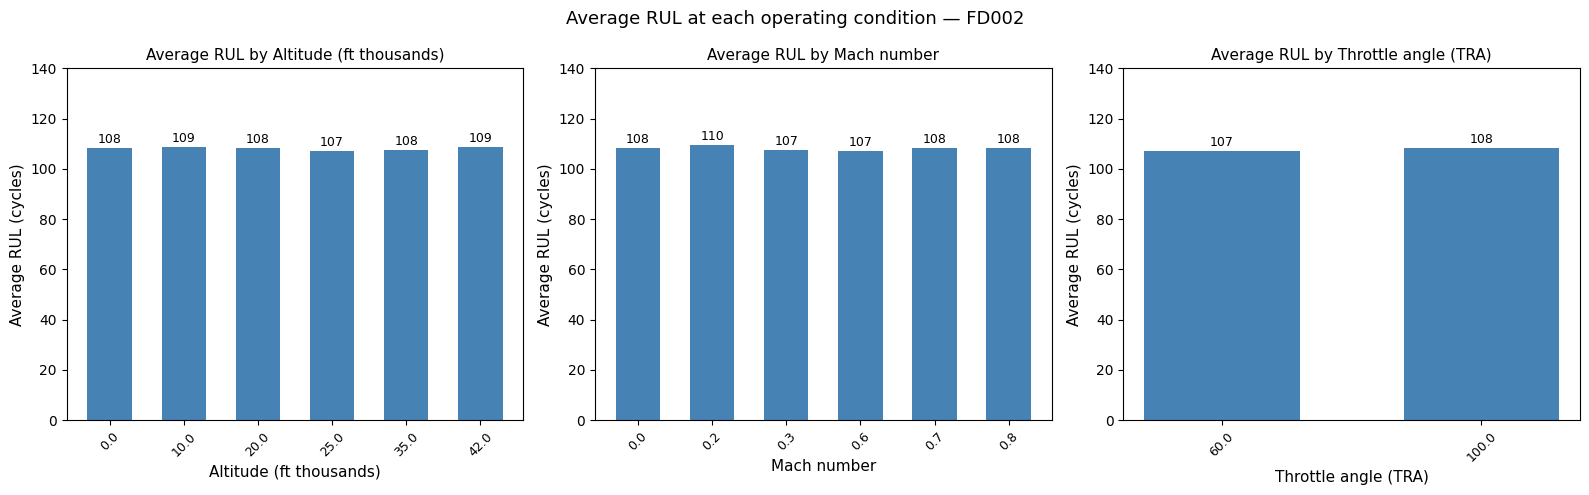

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Average RUL at each operating condition — FD002', fontsize=13)

subset = df_train[df_train['dataset'] == 2].copy()
subset['op1_rounded'] = subset['op1'].round(0)
subset['op2_rounded'] = subset['op2'].round(1)

ops = ['op1_rounded', 'op2_rounded', 'op3']
op_names = ['Altitude (ft thousands)', 'Mach number', 'Throttle angle (TRA)']

for col, (op, name) in enumerate(zip(ops, op_names)):
    mean_rul = subset.groupby(op)['RUL'].mean().reset_index()
    mean_rul = mean_rul.sort_values(op)
    
    axes[col].bar(range(len(mean_rul)), mean_rul['RUL'],
                  color='steelblue', edgecolor='none', width=0.6)
    axes[col].set_xticks(range(len(mean_rul)))
    axes[col].set_xticklabels(mean_rul[op].astype(str), rotation=45, fontsize=9)
    axes[col].set_xlabel(name, fontsize=11)
    axes[col].set_ylabel('Average RUL (cycles)', fontsize=11)
    axes[col].set_title(f'Average RUL by {name}', fontsize=11)
    axes[col].set_ylim(0, 140)
    
    for i, row in enumerate(mean_rul['RUL']):
        axes[col].text(i, row + 2, f'{row:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Sensors Which Show the Most to the Degradation Of Engine

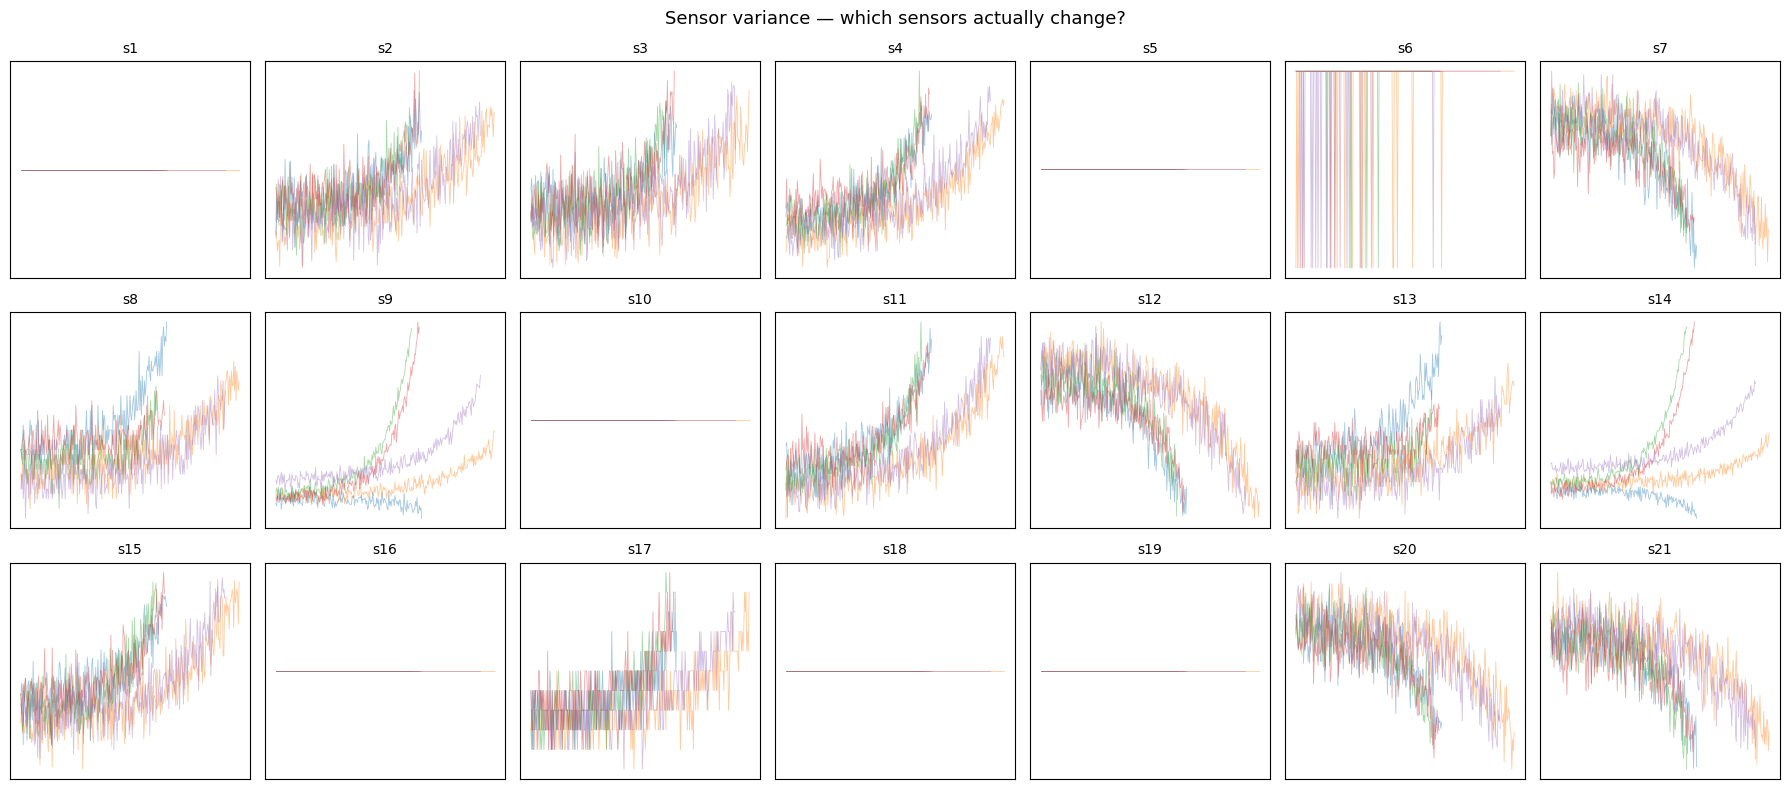

In [9]:
sensor_cols = [f's{i}' for i in range(1, 22)]

fig, axes = plt.subplots(3, 7, figsize=(18, 8))
fig.suptitle('Sensor variance — which sensors actually change?', fontsize=13)
axes = axes.flatten()

for idx, sensor in enumerate(sensor_cols):
    subset = df_train[df_train['dataset'] == 1]
    for engine_id in subset['unit'].unique()[:5]:
        engine_data = subset[subset['unit'] == engine_id]
        axes[idx].plot(engine_data['cycle'], engine_data[sensor], alpha=0.4, linewidth=0.6)
    axes[idx].set_title(sensor, fontsize=10)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.tight_layout()
plt.show()

In [10]:
flat_sensors = ['s1', 's5', 's10', 's16', 's18', 's19']
useful_sensors = [s for s in [f's{i}' for i in range(1, 22)] if s not in flat_sensors]

print("Dropped sensors:", flat_sensors)
print("Useful sensors:", useful_sensors)
print("Number of useful sensors:", len(useful_sensors))



Dropped sensors: ['s1', 's5', 's10', 's16', 's18', 's19']
Useful sensors: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Number of useful sensors: 15


##  Feature Engineering

###  Rolling Sensor Statistics (30-cycle window)

In [11]:
def create_rolling_features(df, window=30):
    result = df.copy()
    
    for sensor in useful_sensors:
        grouped = df.groupby(['dataset', 'unit'])[sensor]
        
        result[f'{sensor}_mean'] = grouped.transform(lambda x: x.rolling(window, min_periods=1).mean())
        result[f'{sensor}_std']  = grouped.transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        result[f'{sensor}_min']  = grouped.transform(lambda x: x.rolling(window, min_periods=1).min())
        result[f'{sensor}_max']  = grouped.transform(lambda x: x.rolling(window, min_periods=1).max())
        result[f'{sensor}_diff'] = grouped.transform(lambda x: x.diff().fillna(0))
    
    return result

df_train_fe = create_rolling_features(df_train)
print("Shape:", df_train_fe.shape)
print("s11_mean sample:", df_train_fe['s11_mean'].head(3).values)

        

Shape: (160359, 103)
s11_mean sample: [47.47 47.48 47.41]


### Sensor Variance Analysis — Dropping Flat Sensors

In [12]:
df_train_fe = df_train_fe.rename(columns={'cycle_x': 'cycle'})


max_cycles = df_train_fe.groupby(['dataset', 'unit'])['cycle'].max().reset_index()
max_cycles.columns = ['dataset', 'unit', 'max_cycle']

df_train_fe = df_train_fe.merge(max_cycles, on=['dataset', 'unit'], how='left')

df_train_fe['cycle_normalized']    = df_train_fe['cycle'] / df_train_fe['max_cycle']
df_train_fe['cycle_pct_remaining'] = 1 - df_train_fe['cycle_normalized']

df_train_fe = df_train_fe.drop('max_cycle', axis=1)

print("New shape:", df_train_fe.shape)
print(df_train_fe[['unit', 'cycle', 'cycle_normalized', 'cycle_pct_remaining', 'RUL']].head(10))

New shape: (160359, 105)
   unit  cycle  cycle_normalized  cycle_pct_remaining  RUL
0     1      1          0.005208             0.994792  191
1     1      2          0.010417             0.989583  190
2     1      3          0.015625             0.984375  189
3     1      4          0.020833             0.979167  188
4     1      5          0.026042             0.973958  187
5     1      6          0.031250             0.968750  186
6     1      7          0.036458             0.963542  185
7     1      8          0.041667             0.958333  184
8     1      9          0.046875             0.953125  183
9     1     10          0.052083             0.947917  182


###  Rolling Features on Test Set

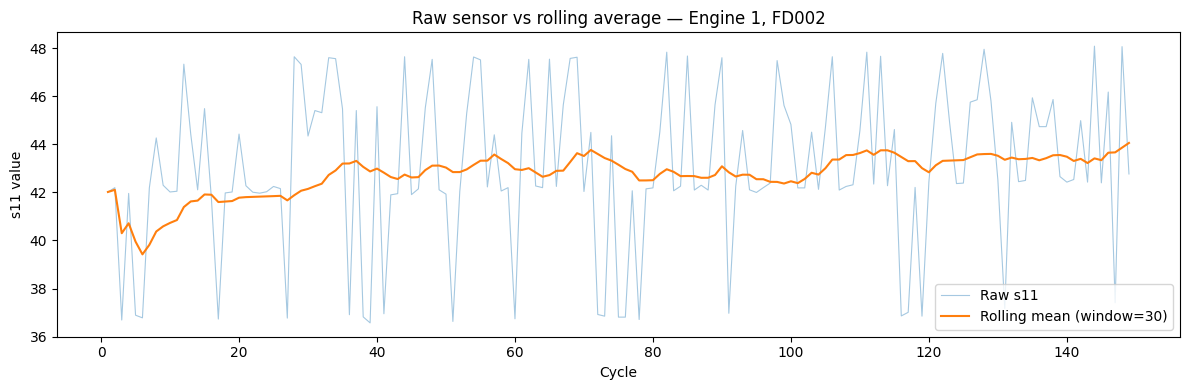

In [13]:
engine_data = df_train_fe[(df_train_fe['dataset'] == 2) & (df_train_fe['unit'] == 1)]

plt.figure(figsize=(12, 4))
plt.plot(engine_data['cycle'], engine_data['s11'], alpha=0.4, linewidth=0.8, label='Raw s11')
plt.plot(engine_data['cycle'], engine_data['s11_mean'], linewidth=1.5, label='Rolling mean (window=30)')
plt.xlabel('Cycle')
plt.ylabel('s11 value')
plt.title('Raw sensor vs rolling average — Engine 1, FD002')
plt.legend()
plt.tight_layout()
plt.show()

### Cycle Normalized Vs RUL

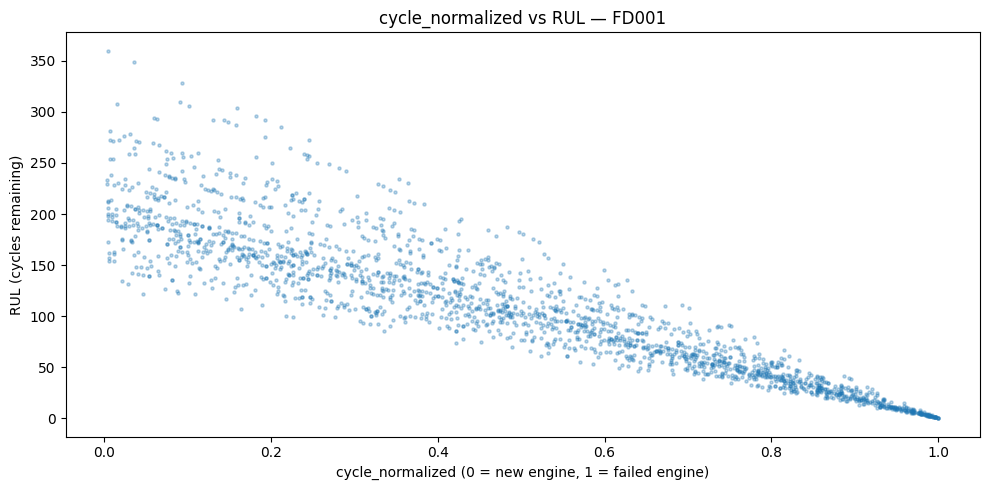

In [14]:
sample = df_train_fe[df_train_fe['dataset'] == 1].sample(2000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['cycle_normalized'], sample['RUL'], alpha=0.3, s=5)
plt.xlabel('cycle_normalized (0 = new engine, 1 = failed engine)')
plt.ylabel('RUL (cycles remaining)')
plt.title('cycle_normalized vs RUL — FD001')
plt.tight_layout()
plt.show()

### Feature Correlation Map

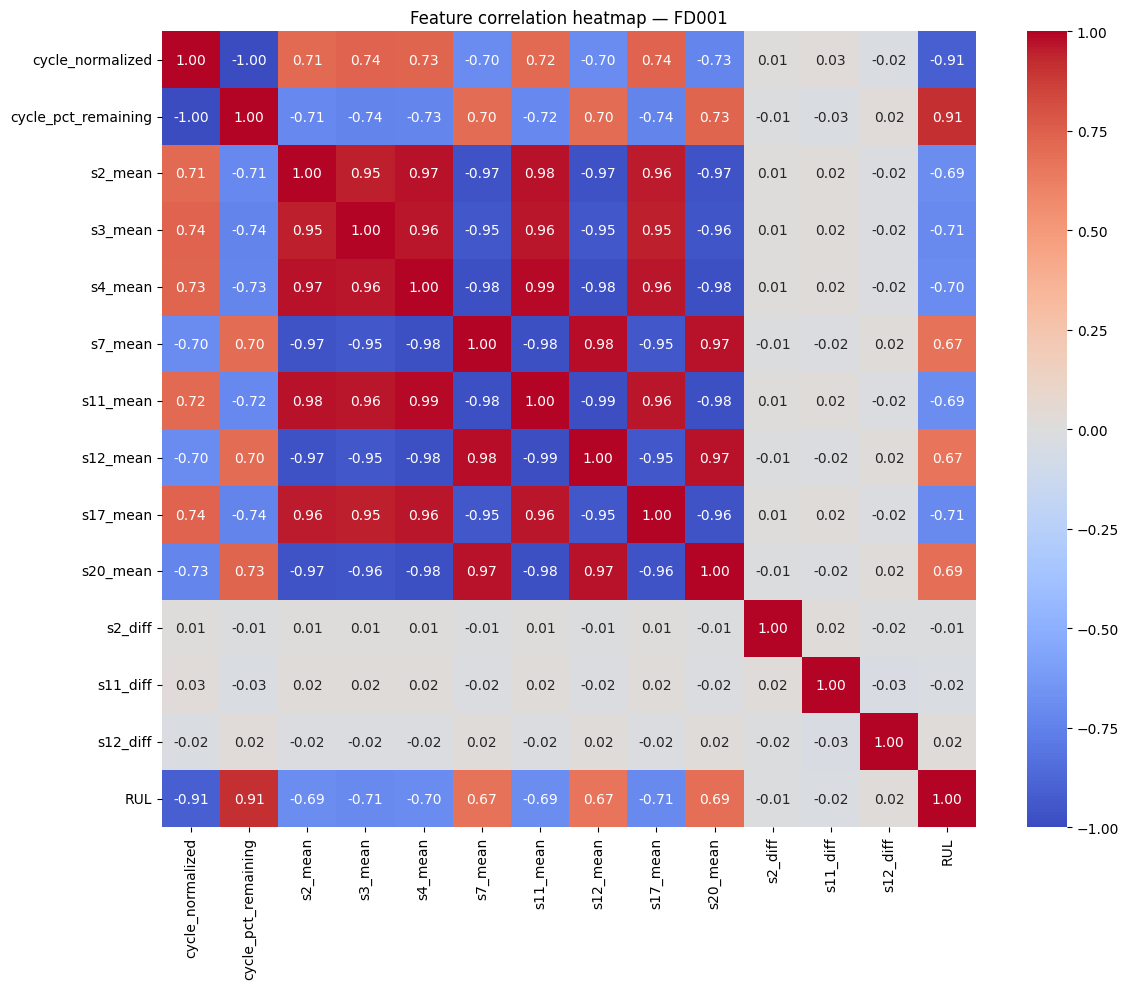

In [15]:
import seaborn as sns

corr_cols = ['cycle_normalized', 'cycle_pct_remaining',
             's2_mean', 's3_mean', 's4_mean', 's7_mean',
             's11_mean', 's12_mean', 's17_mean', 's20_mean',
             's2_diff', 's11_diff', 's12_diff', 'RUL']

corr_matrix = df_train_fe[df_train_fe['dataset'] == 1][corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation heatmap — FD001')
plt.tight_layout()
plt.show()

### Rate of Change of s11

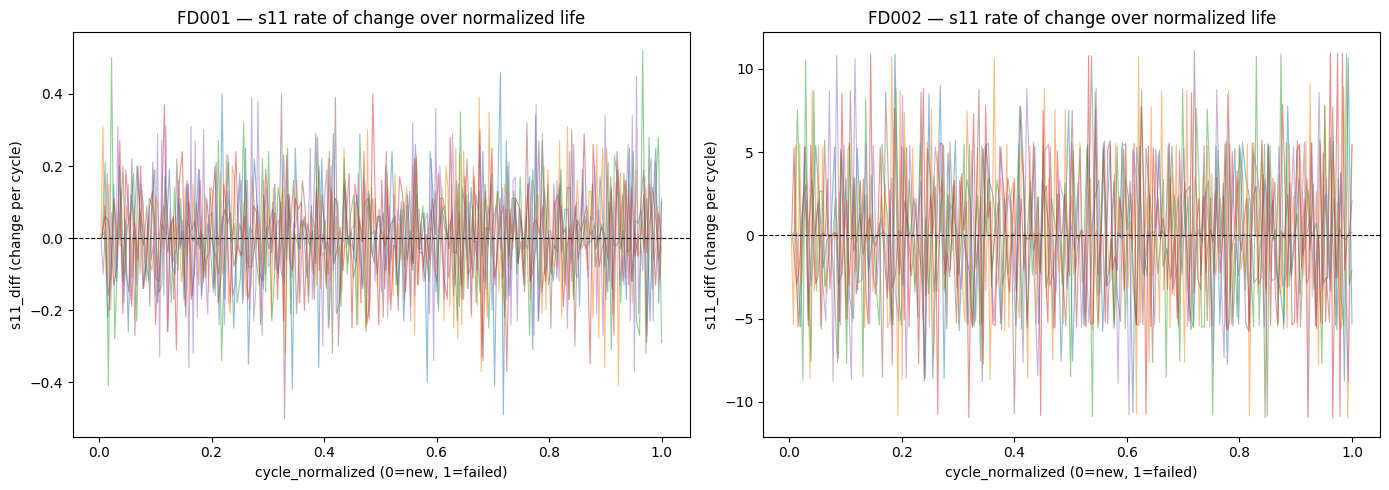

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset_num in zip(axes, [1, 2]):
    subset = df_train_fe[df_train_fe['dataset'] == dataset_num]
    
    for engine_id in subset['unit'].unique()[:6]:
        engine_data = subset[subset['unit'] == engine_id]
        ax.plot(engine_data['cycle_normalized'], engine_data['s11_diff'], 
                alpha=0.5, linewidth=0.8)
    
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'FD00{dataset_num} — s11 rate of change over normalized life')
    ax.set_xlabel('cycle_normalized (0=new, 1=failed)')
    ax.set_ylabel('s11_diff (change per cycle)')

plt.tight_layout()
plt.show()


## Model Building

### Feature and Target Definition 

In [17]:
df_test_fe = create_rolling_features(df_test)

df_test_fe = df_test_fe.rename(columns={'cycle_x': 'cycle'})

max_cycles_test = df_test_fe.groupby(['dataset', 'unit'])['cycle'].max().reset_index()
max_cycles_test.columns = ['dataset', 'unit', 'max_cycle']

df_test_fe = df_test_fe.merge(max_cycles_test, on=['dataset', 'unit'], how='left')

df_test_fe['cycle_normalized']    = df_test_fe['cycle'] / df_test_fe['max_cycle']
df_test_fe['cycle_pct_remaining'] = 1 - df_test_fe['cycle_normalized']

df_test_fe = df_test_fe.drop('max_cycle', axis=1)

print("Test shape:", df_test_fe.shape)
print("Train shape:", df_train_fe.shape)
print("Columns match:", list(df_test_fe.columns) == list(df_train_fe.columns))


Test shape: (104897, 104)
Train shape: (160359, 105)
Columns match: False


### Train/Validation Split 

In [18]:
train_cols = set(df_train_fe.columns)
test_cols = set(df_test_fe.columns)

print("In train but not test:", train_cols - test_cols)
print("In test but not train:", test_cols - train_cols)


In train but not test: {'RUL'}
In test but not train: set()


In [19]:
drop_cols=['unit','dataset', 'RUL']
feature_cols=[c for c in df_train_fe.columns if c not in drop_cols]
X = df_train_fe[feature_cols]
y = df_train_fe['RUL']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Sample features:", feature_cols[:10])

Features shape: (160359, 102)
Target shape: (160359,)
Sample features: ['cycle', 'op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])



Training samples: 128287
Validation samples: 32072


### XGBoost Baseline

In [21]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"\nValidation RMSE: {rmse:.2f} cycles")


[0]	validation_0-rmse:80.00924
[100]	validation_0-rmse:11.81119
[200]	validation_0-rmse:6.84219
[300]	validation_0-rmse:5.84002
[400]	validation_0-rmse:5.55998
[499]	validation_0-rmse:5.42966

Validation RMSE: 5.43 cycles


#### Baseline Evaluation 

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

simple_pred = (1 - X_val['cycle_normalized']) * y_val.mean()
simple_rmse = np.sqrt(mean_squared_error(y_val, simple_pred))
print(f"Simple cycle_normalized only RMSE: {simple_rmse:.2f}")

Simple cycle_normalized only RMSE: 83.61


### Predicted vs Actual RUL

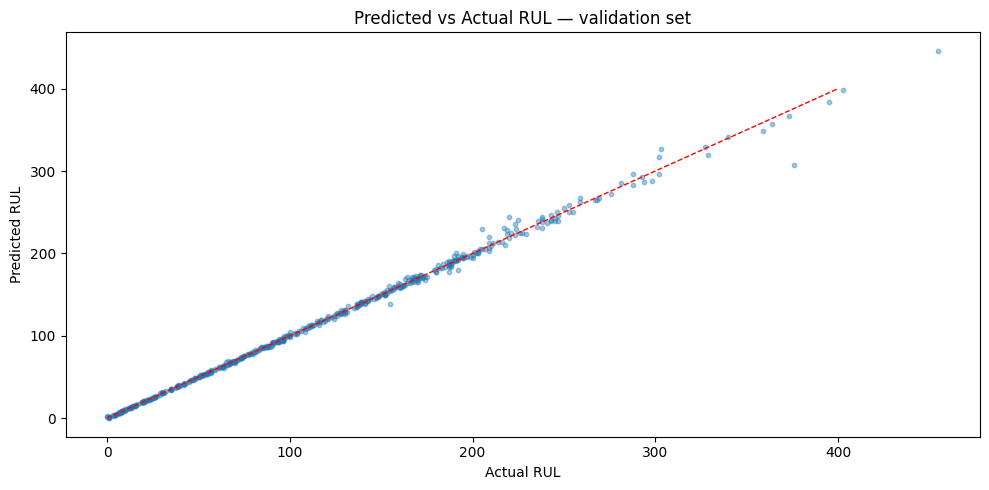

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(y_val[:500], val_preds[:500], alpha=0.4, s=10)
plt.plot([0, 400], [0, 400], 'r--', linewidth=1)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Predicted vs Actual RUL — validation set')
plt.tight_layout()
plt.show()

### Removing Leaky Features

In [24]:
feature_cols_fixed = [c for c in feature_cols if c not in ['cycle_normalized', 'cycle_pct_remaining']]

X_train_fixed = X_train[feature_cols_fixed]
X_val_fixed   = X_val[feature_cols_fixed]

model_fixed = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

model_fixed.fit(
    X_train_fixed, y_train,
    eval_set=[(X_val_fixed, y_val)],
    verbose=100
)

val_preds_fixed = model_fixed.predict(X_val_fixed)
rmse_fixed = np.sqrt(mean_squared_error(y_val, val_preds_fixed))
print(f"\nFixed Validation RMSE: {rmse_fixed:.2f} cycles")


[0]	validation_0-rmse:80.48182
[100]	validation_0-rmse:36.80406
[200]	validation_0-rmse:32.69928
[300]	validation_0-rmse:29.60087
[400]	validation_0-rmse:26.96111
[499]	validation_0-rmse:24.95043

Fixed Validation RMSE: 24.95 cycles


### RUL Capping at 125 Cycles

In [25]:
RUL_CAP = 125

y_train_capped = y_train.clip(upper=RUL_CAP)
y_val_capped   = y_val.clip(upper=RUL_CAP)

model_capped = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

model_capped.fit(
    X_train_fixed, y_train_capped,
    eval_set=[(X_val_fixed, y_val_capped)],
    verbose=100
)

val_preds_capped = model_capped.predict(X_val_fixed)
rmse_capped = np.sqrt(mean_squared_error(y_val_capped, val_preds_capped))
print(f"\nCapped Validation RMSE: {rmse_capped:.2f} cycles")


[0]	validation_0-rmse:39.54757
[100]	validation_0-rmse:14.26045
[200]	validation_0-rmse:12.57347
[300]	validation_0-rmse:11.37441
[400]	validation_0-rmse:10.39555
[499]	validation_0-rmse:9.60635

Capped Validation RMSE: 9.61 cycles


### XGBoost v2 — Capped RU

In [26]:
model_v2 = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse'
)

model_v2.fit(
    X_train_fixed, y_train_capped,
    eval_set=[(X_val_fixed, y_val_capped)],
    verbose=100
)

val_preds_v2 = model_v2.predict(X_val_fixed)
rmse_v2 = np.sqrt(mean_squared_error(y_val_capped, val_preds_v2))
print(f"\nV2 Validation RMSE: {rmse_v2:.2f} cycles")


[0]	validation_0-rmse:39.54757
[100]	validation_0-rmse:14.26045
[200]	validation_0-rmse:12.57347
[300]	validation_0-rmse:11.37441
[400]	validation_0-rmse:10.39555
[500]	validation_0-rmse:9.59646
[600]	validation_0-rmse:8.91263
[700]	validation_0-rmse:8.34033
[800]	validation_0-rmse:7.77891
[900]	validation_0-rmse:7.36520
[999]	validation_0-rmse:6.97731

V2 Validation RMSE: 6.98 cycles


### XGBoost v3 — Extended Training 

In [27]:
model_v3 = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

model_v3.fit(
    X_train_fixed, y_train_capped,
    eval_set=[(X_val_fixed, y_val_capped)],
    verbose=200
)

val_preds_v3 = model_v3.predict(X_val_fixed)
rmse_v3 = np.sqrt(mean_squared_error(y_val_capped, val_preds_v3))
print(f"\nV3 Validation RMSE: {rmse_v3:.2f} cycles")


[0]	validation_0-rmse:39.54757
[200]	validation_0-rmse:12.57347
[400]	validation_0-rmse:10.39555
[600]	validation_0-rmse:8.91263
[800]	validation_0-rmse:7.77891
[1000]	validation_0-rmse:6.97370
[1200]	validation_0-rmse:6.36679
[1400]	validation_0-rmse:5.89248
[1600]	validation_0-rmse:5.54009
[1800]	validation_0-rmse:5.24641
[1999]	validation_0-rmse:5.00618

V3 Validation RMSE: 5.01 cycles


In [28]:
import pickle

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(model_v3, f)

print("Model saved.")


Model saved.


## Evaluation

### Test Set Predictions

In [29]:
X_test_fixed = df_test_fe[feature_cols_fixed]

test_preds = model_v3.predict(X_test_fixed)
test_preds = np.clip(test_preds, 0, 125)

last_cycle_preds = df_test_fe.copy()
last_cycle_preds['predicted_RUL'] = test_preds

engine_preds = last_cycle_preds.groupby(['dataset', 'unit']).last().reset_index()
engine_preds = engine_preds[['dataset', 'unit', 'predicted_RUL']]

engine_preds['risk'] = 'Safe'
engine_preds.loc[engine_preds['predicted_RUL'] <= 60, 'risk'] = 'Warning'
engine_preds.loc[engine_preds['predicted_RUL'] <= 30, 'risk'] = 'Critical'

print(engine_preds['risk'].value_counts())
print(engine_preds.head(10))

risk
Safe        452
Critical    147
Warning     108
Name: count, dtype: int64
   dataset  unit  predicted_RUL  risk
0        1     1     125.000000  Safe
1        1     2     123.331238  Safe
2        1     3      65.245728  Safe
3        1     4      82.987862  Safe
4        1     5      94.243210  Safe
5        1     6      99.618385  Safe
6        1     7      95.153542  Safe
7        1     8      78.267967  Safe
8        1     9     119.113419  Safe
9        1    10      77.442703  Safe


###  RUL Prediction by Dataset

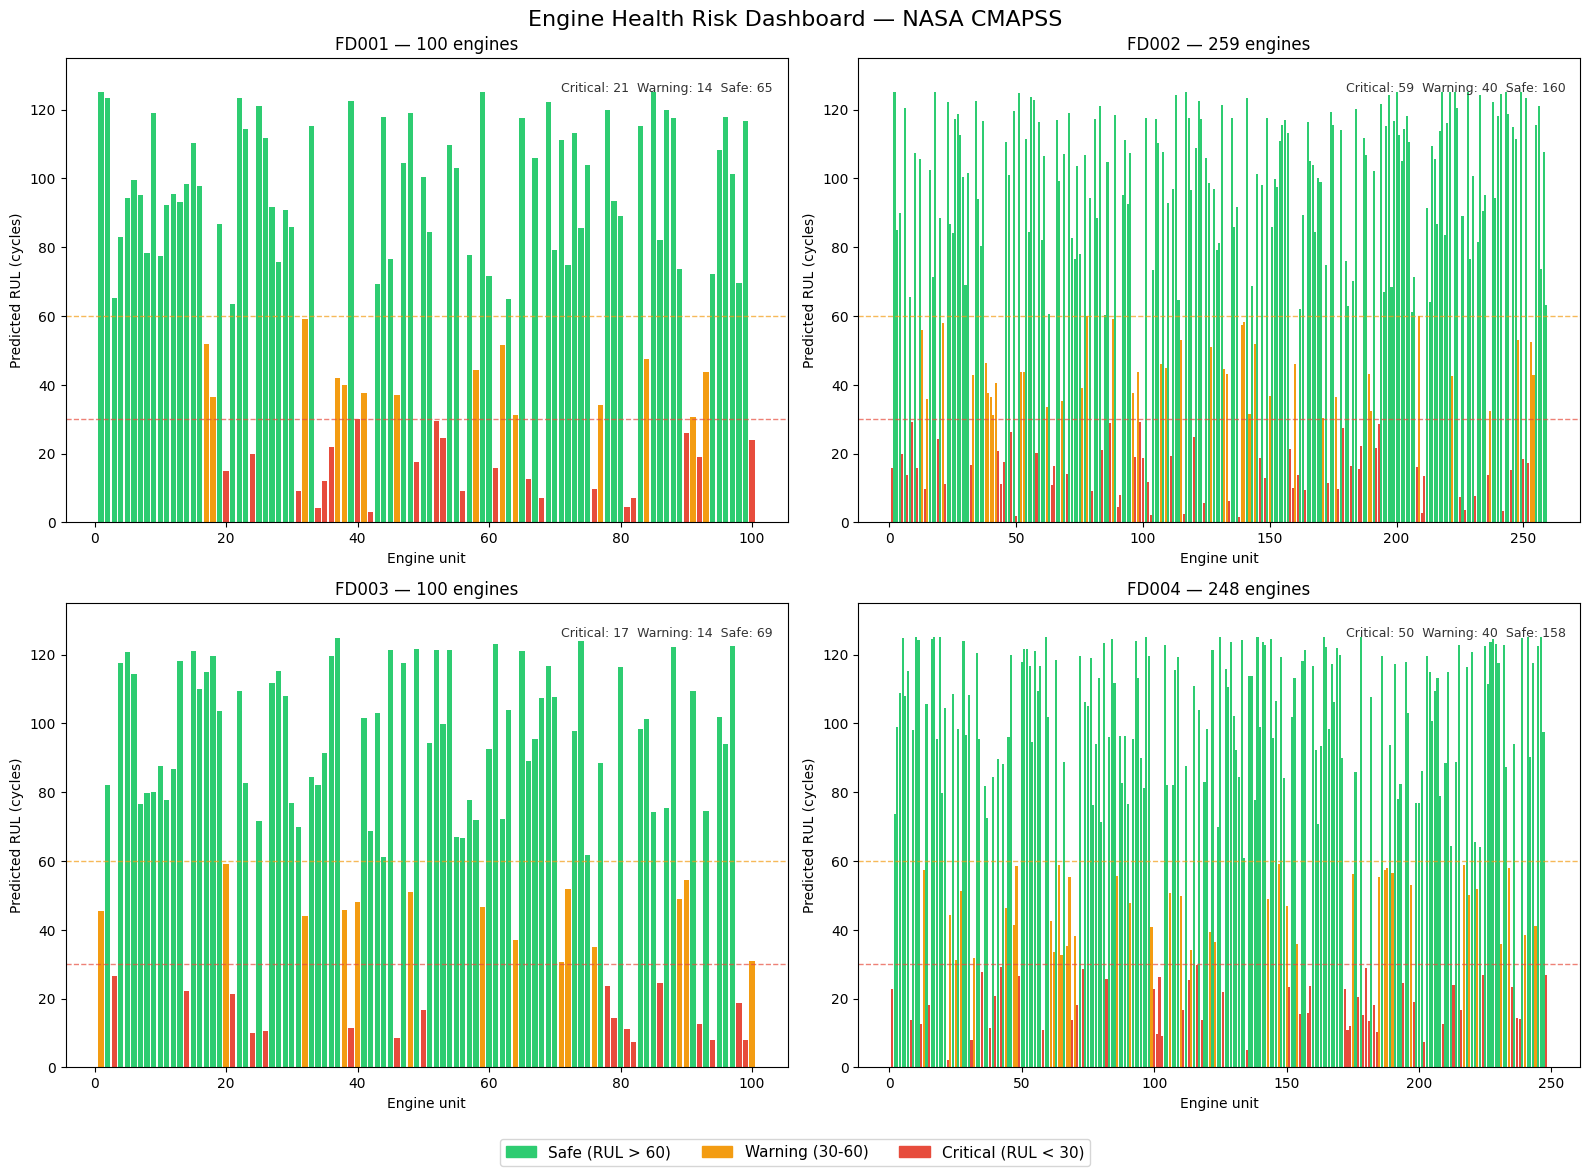

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Engine Health Risk Dashboard — NASA CMAPSS', fontsize=16)

colors = {'Safe': '#2ecc71', 'Warning': '#f39c12', 'Critical': '#e74c3c'}

for idx, dataset_num in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2][idx % 2]
    subset = engine_preds[engine_preds['dataset'] == dataset_num].reset_index(drop=True)
    
    bar_colors = [colors[r] for r in subset['risk']]
    bars = ax.bar(subset['unit'], subset['predicted_RUL'], color=bar_colors, edgecolor='none', width=0.8)
    
    ax.axhline(y=30, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.7)
    ax.axhline(y=60, color='#f39c12', linewidth=1, linestyle='--', alpha=0.7)
    
    ax.set_title(f'FD00{dataset_num} — {len(subset)} engines', fontsize=12)
    ax.set_xlabel('Engine unit')
    ax.set_ylabel('Predicted RUL (cycles)')
    ax.set_ylim(0, 135)
    
    n_critical = len(subset[subset['risk'] == 'Critical'])
    n_warning  = len(subset[subset['risk'] == 'Warning'])
    n_safe     = len(subset[subset['risk'] == 'Safe'])
    ax.text(0.98, 0.95, f'Critical: {n_critical}  Warning: {n_warning}  Safe: {n_safe}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            color='#333333')

patches = [
    mpatches.Patch(color='#2ecc71', label='Safe (RUL > 60)'),
    mpatches.Patch(color='#f39c12', label='Warning (30-60)'),
    mpatches.Patch(color='#e74c3c', label='Critical (RUL < 30)')
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11, 
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


###  Metrics — MAE, RMSE, R² 

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

val_preds_v3 = model_v3.predict(X_val_fixed)
val_preds_v3 = np.clip(val_preds_v3, 0, 125)
y_val_capped_check = y_val.clip(upper=125)

rmse  = np.sqrt(mean_squared_error(y_val_capped_check, val_preds_v3))
mae   = mean_absolute_error(y_val_capped_check, val_preds_v3)
r2    = r2_score(y_val_capped_check, val_preds_v3)

within_10 = np.mean(np.abs(val_preds_v3 - y_val_capped_check) <= 10) * 100
within_20 = np.mean(np.abs(val_preds_v3 - y_val_capped_check) <= 20) * 100

print("=" * 40)
print("Final Model Evaluation")
print("=" * 40)
print(f"RMSE        : {rmse:.2f} cycles")
print(f"MAE         : {mae:.2f} cycles")
print(f"R2 Score    : {r2:.4f}")
print(f"Within 10   : {within_10:.1f}%")
print(f"Within 20   : {within_20:.1f}%")
print("=" * 40)

Final Model Evaluation
RMSE        : 4.96 cycles
MAE         : 3.24 cycles
R2 Score    : 0.9855
Within 10   : 93.8%
Within 20   : 99.5%


### 6.4 Model Fact Check

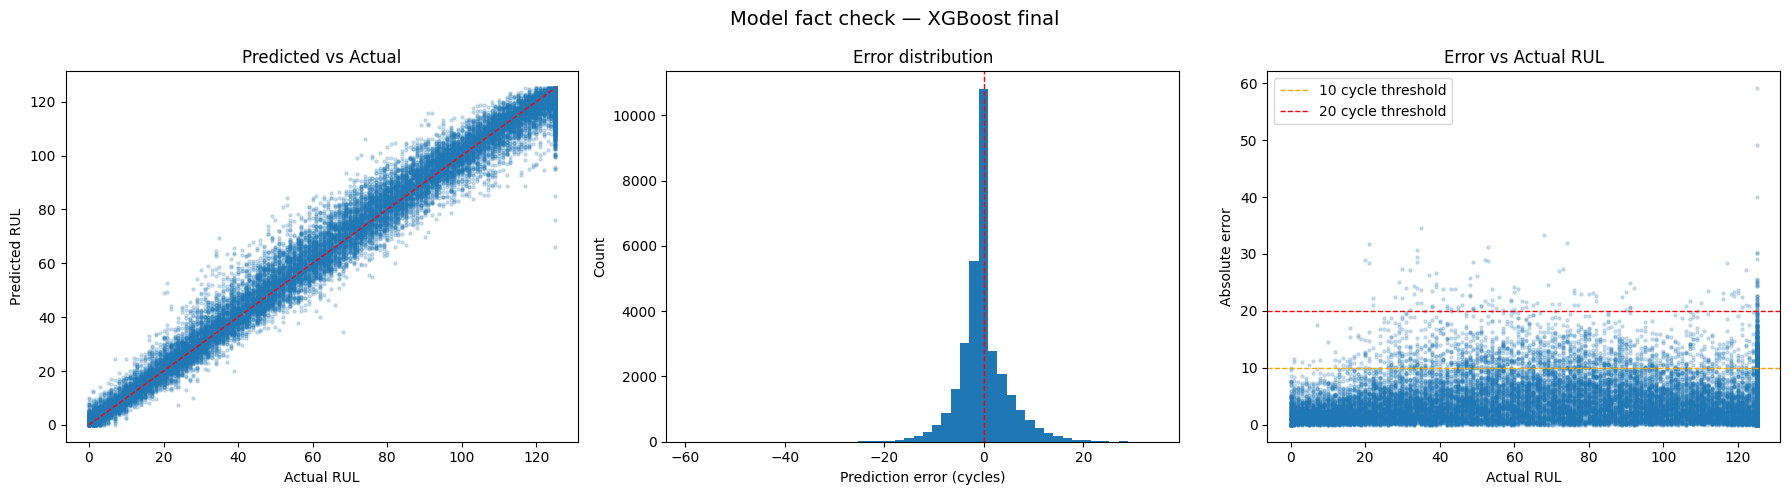

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model fact check — XGBoost final', fontsize=14)

axes[0].scatter(y_val_capped_check, val_preds_v3, alpha=0.2, s=5)
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1)
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('Predicted vs Actual')

errors = val_preds_v3 - y_val_capped_check
axes[1].hist(errors, bins=50, edgecolor='none')
axes[1].axvline(x=0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel('Prediction error (cycles)')
axes[1].set_ylabel('Count')
axes[1].set_title('Error distribution')

axes[2].scatter(y_val_capped_check, np.abs(errors), alpha=0.2, s=5)
axes[2].axhline(y=10, color='orange', linewidth=1, linestyle='--', label='10 cycle threshold')
axes[2].axhline(y=20, color='red', linewidth=1, linestyle='--', label='20 cycle threshold')
axes[2].set_xlabel('Actual RUL')
axes[2].set_ylabel('Absolute error')
axes[2].set_title('Error vs Actual RUL')
axes[2].legend()

plt.tight_layout()
plt.show()


### 6.5 Maintenance Probability Analysis

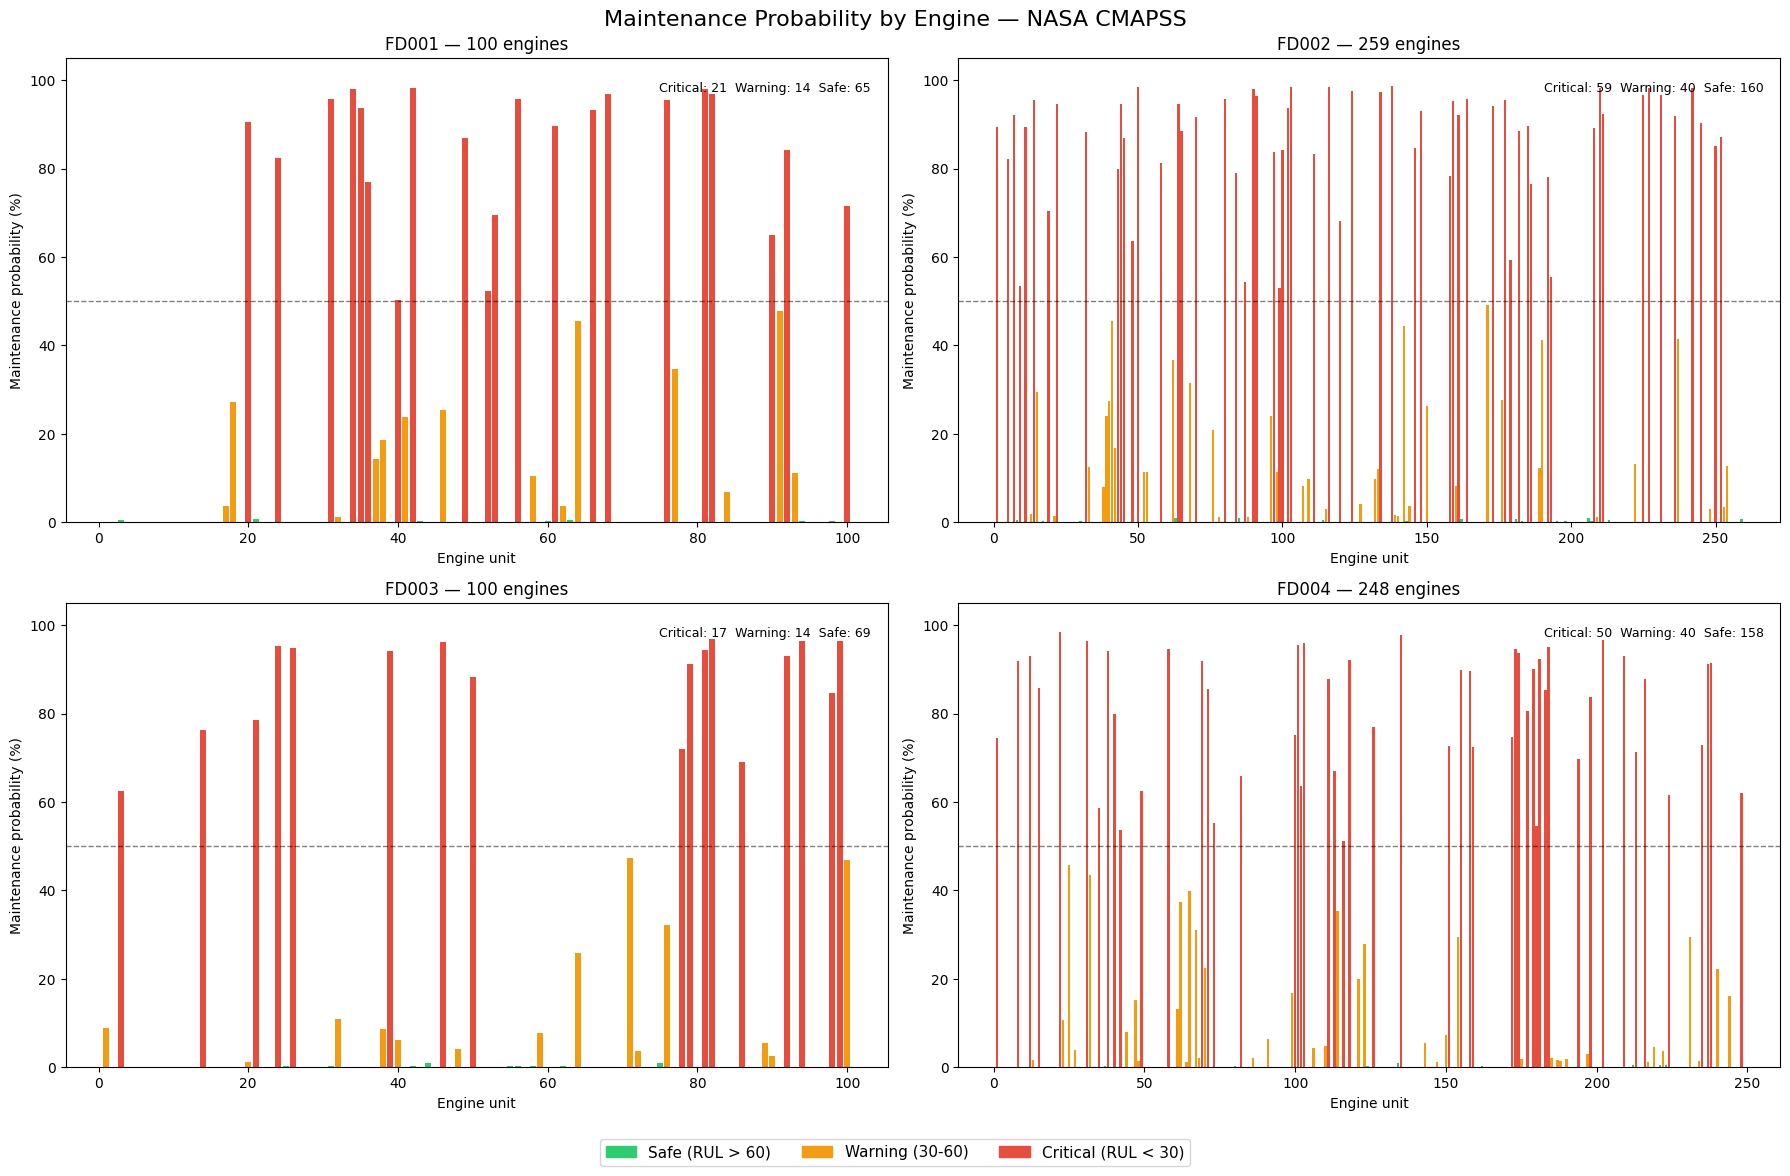


Top 10 engines needing urgent maintenance:
 dataset  unit  predicted_RUL  maintenance_probability     risk
       2   138       1.645029                     98.6 Critical
       4    22       2.003112                     98.5 Critical
       2   103       2.077550                     98.5 Critical
       2    50       1.876499                     98.5 Critical
       2   116       2.501338                     98.4 Critical
       1    42       2.999842                     98.3 Critical
       2   210       2.807924                     98.3 Critical
       2   242       3.327074                     98.2 Critical
       2   227       3.683871                     98.1 Critical
       1    34       4.182636                     98.0 Critical


In [35]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Maintenance Probability by Engine — NASA CMAPSS', fontsize=16)

colors = {'Safe': '#2ecc71', 'Warning': '#f39c12', 'Critical': '#e74c3c'}

for idx, dataset_num in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2][idx % 2]
    subset = engine_preds[engine_preds['dataset'] == dataset_num].reset_index(drop=True)

    bar_colors = [colors[r] for r in subset['risk']]
    ax.bar(subset['unit'], subset['maintenance_probability'],
           color=bar_colors, edgecolor='none', width=0.8)

    ax.axhline(y=50, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_title(f'FD00{dataset_num} — {len(subset)} engines', fontsize=12)
    ax.set_xlabel('Engine unit')
    ax.set_ylabel('Maintenance probability (%)')
    ax.set_ylim(0, 105)

    n_critical = len(subset[subset['risk'] == 'Critical'])
    n_warning  = len(subset[subset['risk'] == 'Warning'])
    n_safe     = len(subset[subset['risk'] == 'Safe'])
    ax.text(0.98, 0.95, f'Critical: {n_critical}  Warning: {n_warning}  Safe: {n_safe}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color='#2ecc71', label='Safe (RUL > 60)'),
    mpatches.Patch(color='#f39c12', label='Warning (30-60)'),
    mpatches.Patch(color='#e74c3c', label='Critical (RUL < 30)')
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print("\nTop 10 engines needing urgent maintenance:")
print(engine_preds.sort_values('maintenance_probability', ascending=False)
      [['dataset', 'unit', 'predicted_RUL', 'maintenance_probability', 'risk']]
      .head(10).to_string(index=False))



